In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')

In [4]:
print("=== Shape ===")
print(df.shape)
print("\n=== Info ===")
print(df.info())
print("\n=== Describe ===")
print(df.describe())

missing_pct = (df.isnull().sum() / len(df)) * 100
print("\n=== Missing percentages ===")
print(missing_pct.round(2))

df.to_csv("titanic.csv", index=False)

=== Shape ===
(891, 15)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

=== Describe ===
         survived 

In [5]:
cols_with_missing = missing_pct[missing_pct > 0].index.tolist()

print("\n=== Columns with missing values ===")

for col in cols_with_missing:
    print(f"{col}: {missing_pct[col]:.2f}%")

for col in cols_with_missing:
    pct = missing_pct[col]

    if pct < 5:
        print(f"{col}: drop rows ({pct:.2f}% < 5%)")
        df = df.dropna(subset=[col])

    elif pct <= 30:
        print(f"{col}: impute ({pct:.2f}% in [5%, 30%])")

        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        print(f"{col}: drop column ({pct:.2f}% > 30%)")
        df = df.drop(columns=[col])


=== Columns with missing values ===
age: 19.87%
embarked: 0.22%
deck: 77.22%
embark_town: 0.22%
age: impute (19.87% in [5%, 30%])
embarked: drop rows (0.22% < 5%)
deck: drop column (77.22% > 30%)
embark_town: drop rows (0.22% < 5%)


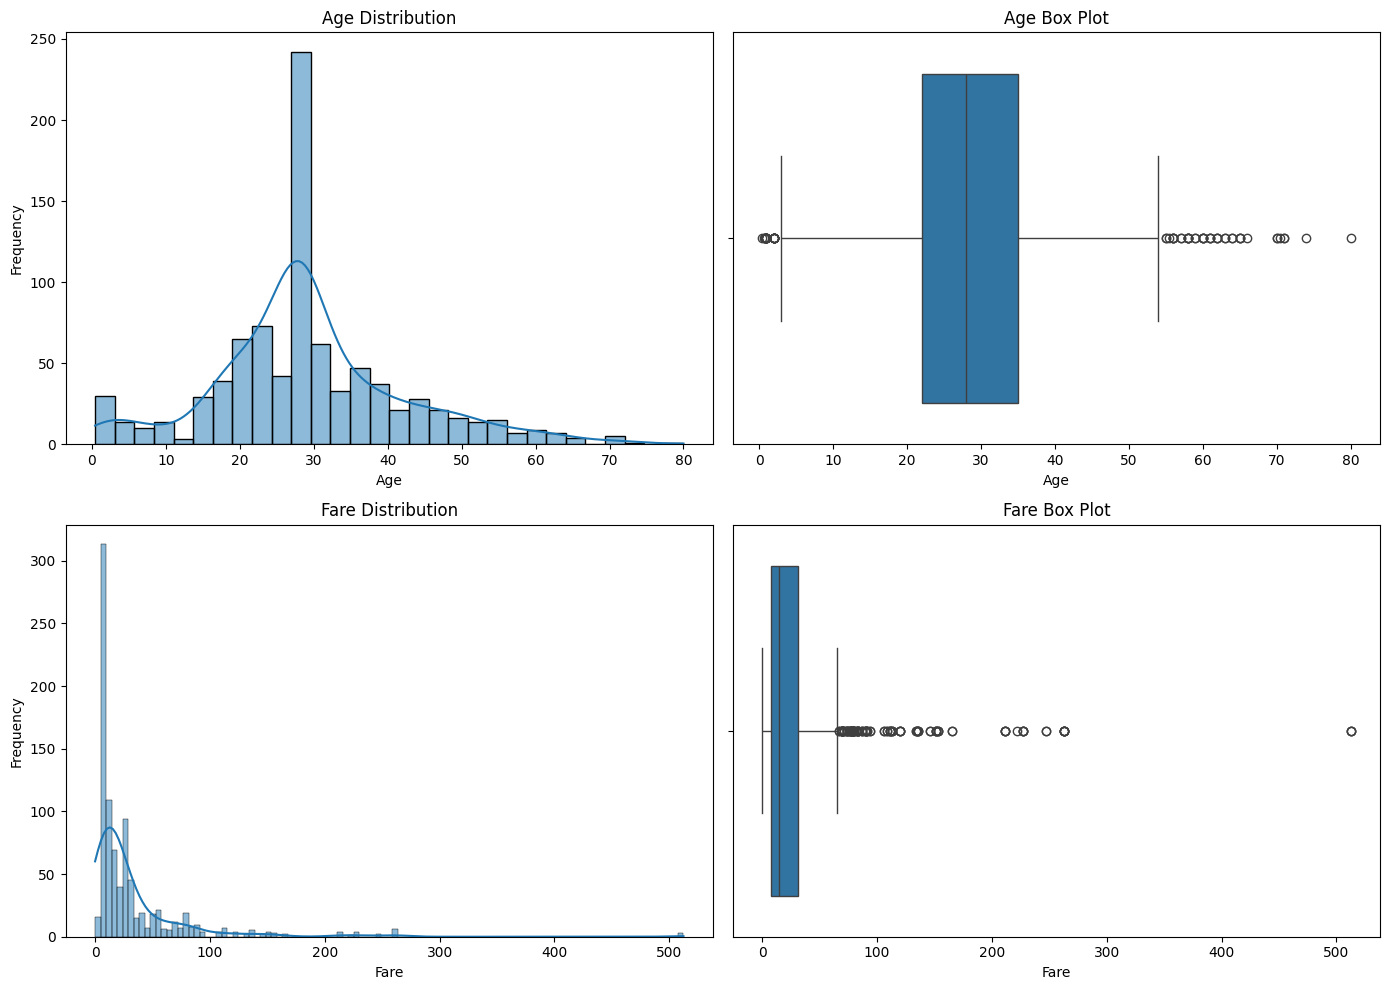


Age outliers (IQR): 65
Fare outliers (IQR): 114

Fare mean: 32.10
Fare median: 14.45
Fare mode: 8.05
Fare skewness: 4.801
Distribution is right-skewed.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

sns.boxplot(x=df["age"], ax=axes[0, 1])
axes[0, 1].set_title("Age Box Plot")
axes[0, 1].set_xlabel("Age")

sns.histplot(df["fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Distribution")
axes[1, 0].set_xlabel("Fare")
axes[1, 0].set_ylabel("Frequency")

sns.boxplot(x=df["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Box Plot")
axes[1, 1].set_xlabel("Fare")

plt.tight_layout()
plt.savefig("eda_hist_box.png", dpi=150)
plt.show()

def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

age_outliers = count_outliers_iqr(df['age'])
fare_outliers = count_outliers_iqr(df['fare'])

print(f"\nAge outliers (IQR): {age_outliers}")
print(f"Fare outliers (IQR): {fare_outliers}")


print(f"\nFare mean: {df['fare'].mean():.2f}")
print(f"Fare median: {df['fare'].median():.2f}")
print(f"Fare mode: {df['fare'].mode()[0]:.2f}")
print(f"Fare skewness: {df['fare'].skew():.3f}")

if df['fare'].skew() > 0.5:
    print("Distribution is right-skewed.")
elif df['fare'].skew() < -0.5:
    print("Distribution is left-skewed.")
else:
    print("Distribution is symmetric.")

In [ ]:
surv_sex = df.groupby("sex")["survived"].mean() * 100
print("\n=== Survival rate by sex ===")
print(surv_sex.round(2))

surv_pclass = df.groupby('pclass')['survived'].mean() * 100
print("\n=== Survival rate by pclass ===")
print(surv_pclass.round(2))

surv_sex_pclass = df.groupby(['sex', 'pclass'])['survived'].mean() * 100
print("\n=== Survival rate by sex and pclass ===")
print(surv_sex_pclass.round(2))

corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()
print("\n=== Correlation matrix ===")
print(corr_matrix.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (6 columns)')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

survived_corr = (corr_matrix["survived"].drop("survived").abs().sort_values(ascending=False))
print("\n=== Top 2 strongest correlation (by abs) ===")
print(survived_corr.head(2))

In [ ]:
numeric_cols = ['age', 'fare']

print("\n=== Before standardization ===")
print(df[numeric_cols].describe().round(3))

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\n=== After standardization ===")
print(df[numeric_cols].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Age (Standardized)')
axes[0].set_xlabel('Standardized Age')

sns.histplot(df['fare'], kde=True, ax=axes[1])
axes[1].set_title('Fare (Standardized)')
axes[1].set_xlabel('Standardized Fare')

plt.tight_layout()
plt.savefig('standardization_comparison.png', dpi=150)
plt.show()
